---
title: "[Run LegalRAG Pipeline](https://colab.research.google.com/drive/14ZMPCSyrkh6gcV74SI5yIFfgdeJ8OMA9?usp=sharing)"
---



This notebook demonstrates the full pipeline behavior of Legal RAG system: data preprocess, query understanding, routing, hybrid retrieval, and generate answer.

## Repository Install

First, pull the project source code and initialize the execution environment.

```python
git clone https://github.com/Fan-Luo/Legal-RAG.git
cd Legal-RAG
pip install -e .
```


In [ ]:
#| include: false

import logging

def setup_logging(
    level=logging.INFO,
    fmt="%(message)s",
    scope="legalrag",
):
    """
    Configure logging for the LegalRAG repository.

    This function removes existing handlers attached to loggers
    under the given scope and installs a clean StreamHandler.
    """
    base = logging.getLogger(scope)
    base.setLevel(level)

    # Remove all handlers under this scope
    for name, logger in logging.root.manager.loggerDict.items():
        if name == scope or name.startswith(scope + "."):
            lg = logging.getLogger(name)
            for h in lg.handlers[:]:
                lg.removeHandler(h)
            lg.propagate = False

    # Attach a single handler to base logger
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter(fmt))
    base.addHandler(handler)

setup_logging(fmt="%(message)s")

In [ ]:
#| include: false

from pathlib import Path
import os, subprocess

ROOT = Path("/content").resolve()
REPO_URL = "https://github.com/Fan-Luo/Legal-RAG.git"
REPO_DIR = ROOT / "Legal-RAG"
os.environ["REPO_DIR"] = str(REPO_DIR)

def run(cmd, cwd=None):
    res = subprocess.run(cmd, cwd=cwd, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    if res.returncode != 0:
        tail="\n".join(res.stdout.splitlines()[-40:])
        raise RuntimeError(f"Command failed: {cmd}\n--- output tail ---\n{tail}")
    return res.stdout

# print(f"Working directory: {ROOT}")
if not REPO_DIR.exists():
    run(["git","clone","--depth","1",REPO_URL,str(REPO_DIR)])
    # print(f"Cloned repo to: {REPO_DIR}")
else:
    run(["git","pull"], cwd=str(REPO_DIR))
    # print(f"Updated repo at: {REPO_DIR}")

os.chdir(REPO_DIR)
print("Current dir:", Path.cwd())


Current dir: /content/Legal-RAG


In [ ]:
#| include: false

from scripts.quiet import install_quiet
import subprocess, textwrap

install_quiet()
print("Quiet mode enabled: suppressed noisy logs/warnings; keeping meaningful tables/figures.")

print("Environment check:")
try:
    out = subprocess.run(["nvidia-smi"], text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT).stdout
    # Keep only first ~15 lines to avoid noisy GPU inventory dumps
    print("\n".join(out.splitlines()[:15]))
except Exception:
    print("No GPU detected (this is fine). Using CPU.")

In [ ]:
#| include: false

%%bash
set -e
cd "$REPO_DIR" || exit 1

pip install --upgrade pip
pip install --upgrade -e .
echo "Dependencies installed."

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 37.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Obtaining file:///content/Legal-RAG
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: s


## Data preprocess

Before the LegalRAG pipeline can serve queries, the legal corpus must be transformed into structured, searchable representations.

In the offline preprocessing stage, raw legal texts are converted into normalized data artifacts, retrieval indices, and a legal knowledge graph through the following steps:

1. **Preprocess law files**
   
   Raw legal documents are parsed, cleaned, and normalized into a unified JSONL format. Each legal provision is assigned a stable identifier and enriched with structural metadata such as law name, part, chapter, article number, and source file.

   ```bash
   python -m scripts.preprocess_law
   ```

2. **Build retrieval indices**
   
   Multiple complementary retrieval indices are constructed to support lexical, dense, and late-interaction search paradigms:

   * **BM25** for sparse keyword-based retrieval
   * **FAISS** for dense vector similarity search
   * **ColBERT** for token-level late interaction retrieval

   ```bash
   python -m scripts.build_index
   ```

3. **Construct the legal knowledge graph**
   
   Legal articles are connected via structured relationships (e.g., citation, reference, dependency), forming a directed legal knowledge graph that enables graph-based expansion and contextual reasoning.

   ```bash
   python -m scripts.build_graph
   ```



In [ ]:
#| include: false

from pathlib import Path
import os

RAW_DIR = Path("data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)
print("Raw dir:", RAW_DIR.resolve())
print("Raw files:", list(RAW_DIR.iterdir()))

try:
    !python -m scripts.preprocess_law
except SystemExit:
    print("Preprocessing completed.")

try:
    !python -m scripts.build_index
except SystemExit:
    print("Index building completed.")

try:
    !python -m scripts.build_graph
except SystemExit:
    print("Law graph building completed.")

print("\nProcessed:")
!ls -R data/processed || echo "no processed dir"
print("\nIndex:")
!ls -R data/index || echo "no index dir"
print("\nGraph:")
!ls -R data/graph || echo "no graph dir"


Raw dir: /content/Legal-RAG/data/raw
Raw files: [PosixPath('data/raw/minfadian.txt')]
2026-01-20 16:29:27,453 - __main__ - INFO - Raw dir: /content/Legal-RAG/data/raw
2026-01-20 16:29:27,453 - __main__ - INFO - Found txt files: ['minfadian.txt']
2026-01-20 16:29:27,453 - __main__ - INFO - Parsing: /content/Legal-RAG/data/raw/minfadian.txt
2026-01-20 16:29:27,454 - __main__ - INFO - File size: 111320 chars
2026-01-20 16:29:27,478 - __main__ - INFO - Parsed records from minfadian.txt: 1260
2026-01-20 16:29:27,478 - __main__ - INFO - Total records: 1260
2026-01-20 16:29:27,487 - __main__ - INFO - Saved JSONL to /content/Legal-RAG/data/processed/law.jsonl
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/u

**Generated Data Artifacts:**

In [ ]:
#| echo: false
#| code-fold: false

from pathlib import Path
import pandas as pd

BASE = Path("data")
targets = [
    BASE / "processed" / "law.jsonl",
    BASE / "index" / "bm25.pkl",
    BASE / "index" / "faiss" / "faiss.index",
    BASE / "index" / "faiss" / "faiss_meta.jsonl",
    # BASE / "index" / "colbert" / "experiments" / "indexes"  / "law" / "0.codes.pt",
    BASE / "index" / "colbert" / "colbert_meta.jsonl",
    BASE / "graph" / "law_graph.jsonl",
]

rows = []
for p in targets:
    rows.append({
        "Category": (
            "Processed"
            if "processed" in p.parts
            else ("Graph" if "graph" in p.parts else "Index")
        ),
        "Path": str(p),
        "Exists": p.exists(),
        "Size (MB)": round(p.stat().st_size / (1024**2), 3) if p.exists() else None,
    })

df = pd.DataFrame(rows).sort_values(["Category", "Path"])
df


,Category,Path,Exists,Size (MB)
5,Graph,data/graph/law_graph.jsonl,True,0.425
1,Index,data/index/bm25.pkl,True,1.008
4,Index,data/index/colbert/colbert_meta.jsonl,True,0.672
2,Index,data/index/faiss/faiss.index,True,4.018
3,Index,data/index/faiss/faiss_meta.jsonl,True,0.622
0,Processed,data/processed/law.jsonl,True,0.705



The processed legal corpus contains 1,260 normalized JSON record with the schema:

| Field        | Description                     |
| ------------ | ------------------------------- |
| `id`         | Internal numeric identifier     |
| `law_name`   | Name of the law                 |
| `part`       | Law part              |
| `chapter`    | Chapter within the law          |
| `article_no` | Article number (human-readable) |
| `article_id` | Stable article identifier       |
| `text`       | Full article text               |
| `source`     | Original source file            |

Example entries from `law.jsonl`:

In [ ]:
#| echo: false
#| code-fold: false

import json

jsonl_path = BASE / "processed" / "law.jsonl"
assert jsonl_path.exists(), f"Not found: {jsonl_path}"

n_lines = sum(1 for _ in jsonl_path.open("r", encoding="utf-8"))

samples = []
with jsonl_path.open("r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 3:
            break
        samples.append(json.loads(line))

pd.json_normalize(samples).drop(columns=["subpart", "section", "article_key"])


,id,law_name,part,chapter,article_no,article_id,text,source
0,minfadian.txt::一,中华人民共和国民法典,一编 总 则,一章 基本规定,第一条,1,第一条 为了保护民事主体的合法权益，调整民事关系，维护社会和经济秩序，适应中国特色社会主义发...,minfadian.txt
1,minfadian.txt::二,中华人民共和国民法典,一编 总 则,一章 基本规定,第二条,2,第二条 民法调整平等主体的自然人、法人和非法人组织之间的人身关系和财产关系。,minfadian.txt
2,minfadian.txt::三,中华人民共和国民法典,一编 总 则,一章 基本规定,第三条,3,第三条 民事主体的人身权利、财产权利以及其他合法权益受法律保护，任何组织或者个人不得侵犯。,minfadian.txt


In [ ]:
#| include: false

meta_path = BASE / "index"/ "faiss" / "faiss_meta.jsonl"
assert meta_path.exists(), f"Not found: {meta_path}"

meta_n = sum(1 for _ in meta_path.open("r", encoding="utf-8"))

print(f"faiss_meta.jsonl records: {meta_n}")
print(f"processed jsonl records: {n_lines}")
print("Aligned:", meta_n == n_lines)


faiss_meta.jsonl records: 1260
processed jsonl records: 1260
Aligned: True


## Initialize the RAG pipeline

This section sets up the RAG pipeline and configures the underlying language model. The pipeline is constructed from a centralized configuration, ensuring that retrieval, ranking, and generation components are consistently parameterized.

In [ ]:
#| include: false

from pathlib import Path
from IPython.display import display, Markdown, clear_output
import asyncio
from typing import Any, Optional, List
from legalrag.utils.logger import get_logger
import time
import json as _json

logger = get_logger(__name__)

In [ ]:
#| code-fold: false

from legalrag.pipeline.rag_pipeline import RagPipeline
from legalrag.config import AppConfig

cfg = AppConfig.load(None)
pipeline = RagPipeline(cfg)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


[Jan 20, 16:36:12] #> Loading codec...
[Jan 20, 16:36:12] Loading decompress_residuals_cpp extension (set COLBERT_LOAD_TORCH_EXTENSION_VERBOSE=True for more info)...


/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


[Jan 20, 16:36:12] Loading packbits_cpp extension (set COLBERT_LOAD_TORCH_EXTENSION_VERBOSE=True for more info)...
[Jan 20, 16:36:12] #> Loading IVF...
[Jan 20, 16:36:12] #> Loading doclens...


100%|██████████| 1/1 [00:00<00:00, 4346.43it/s]

...

model-00002-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.56G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

The default configuration uses local Qwen model as the generation model by default, and it can be switched to an OpenAI model:

```python
cfg.llm.provider = "openai"
cfg.llm.model = "gpt-4.1-mini"   
# Requires setting OPENAI_API_KEY in environment variables
```

## Query Understanding and Routing

This step distinguishes between different query types and selects a retrieval mode accordingly.

Accurate query understanding is critical, as it directly influences downstream retrieval strategies and answer generation behavior.

In [ ]:
#| code-summary: "Route the query (Query type and mode) : "
#| code-fold: false

from legalrag.routing.router import QueryRouter
from legalrag.llm.client import LLMClient

llm = LLMClient.from_config(cfg)
router = QueryRouter(llm_client=LLMClient.from_config(cfg), llm_based=cfg.routing.llm_based)
question = '已经有两个亲生孩子的家庭可以再收养一个孩子吗?'
decision = router.route(question)
print('Issue Type: ', decision.issue_type)
print('Task Type: ', decision.task_type)
print('mode: ', decision.mode)

Issue Type:  IssueType.MARRIAGE_FAMILY
Task Type:  TaskType.JUDGE_STYLE
mode:  RoutingMode.RAG


## Retrieve legal provisions

In this stage, the system retrieves candidate legal provisions relevant to the query.

LegalRAG uses a multi-channel retrieval strategy that combines dense semantic search, sparse lexical matching, and late-interaction models. Depending on the retrieval mode inferred during query understanding, a graph-based enhancement stage may be applied to expand the candidate set with structurally related legal provisions. Final ranking is refined using cross-encoder or LLM-based reranking.

In [ ]:
#| include: false

from legalrag.schemas import RetrievalHit
from typing import Any, Optional, List
import pandas as pd

def hits_to_dataframe(hits: List[RetrievalHit]) -> pd.DataFrame:
    rows = []
    for h in hits:
        c = h.chunk
        sb = getattr(h, "score_breakdown", None) or {}
        rows.append(
            {
                "score": f"{float(getattr(h, 'score', 0.0) or 0.0):.2f}",
                "channel": sb.get("channel", ""),
                "article_id": getattr(c, "article_id", ""),
                "chapter": getattr(c, "chapter", ""),
                "preview": (getattr(c, "text", "") or "").replace("\n", " ")[:80] + "...",
            }
        )
    return pd.DataFrame(rows)


In [ ]:
#| code-summary: "Retrieved legal articles are presented for inspection and comparison :"

question = '已经有两个亲生孩子的家庭可以再收养一个孩子吗?'
_, hits, _ = pipeline.retrieve(question, llm, top_k=10, decision=decision)
hits_to_dataframe(hits)


You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


2026-01-20 16:40:30,206 - legalrag.retrieval.bm25_retriever - INFO - [BM25] loaded index with 1260 chunks


Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Loading model from cache /tmp/jieba.cache
DEBUG:jieba:Loading model from cache /tmp/jieba.cache
Loading model cost 1.281 seconds.
DEBUG:jieba:Loading model cost 1.281 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.
/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()



#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input: 已经有两个亲生孩子的家庭可以再收养一个孩子吗?, 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([     0, 250002,      6, 150398,  15658,  18857,   2026,  51921,   8387,
          1441,   2058,   6633,  27670,   1860,   6830,   9131,     32,      2,
        250001, 250001, 250001, 250001, 250001, 250001, 250001, 250001, 250001,
        250001, 250001, 250001, 250001, 250001], device='cuda:0')
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1], device='cuda:0')



,score,channel,article_id,chapter,preview
0,1.04,"[dense, colbert, bm25]",1100,五章 收 养,第一千一百条 无子女的收养人可以收养两名子女；有子女的收养人只能收养一名子女。 收养孤儿、残...
1,0.42,"[dense, colbert]",1099,五章 收 养,第一千零九十九条 收养三代以内旁系同辈血亲的子女，可以不受本法第一千零九十三条第三项、第一千...
2,0.39,"[dense, colbert]",1103,五章 收 养,第一千一百零三条 继父或者继母经继子女的生父母同意，可以收养继子女，并可以不受本法第一千零九...
3,0.37,"[dense, colbert, bm25]",1101,五章 收 养,第一千一百零一条 有配偶者收养子女，应当夫妻共同收养。...
4,0.31,"[bm25, colbert]",699,十三章 保证合同,第六百九十九条 同一债务有两个以上保证人的，保证人应当按照保证合同约定的保证份额，承担保证责...
5,0.26,"[colbert, dense]",1098,五章 收 养,第一千零九十八条 收养人应当同时具备下列条件： （一）无子女或者只有一名子女； （二）有抚养...
6,0.23,"[dense, colbert]",1117,五章 收 养,第一千一百一十七条 收养关系解除后，养子女与养父母以及其他近亲属间的权利义务关系即行消除，与...
7,0.17,"[dense, colbert]",1097,五章 收 养,第一千零九十七条 生父母送养子女，应当双方共同送养。生父母一方不明或者查找不到的，可以单方送...
8,0.14,"[bm25, colbert]",1114,五章 收 养,第一千一百一十四条 收养人在被收养人成年以前，不得解除收养关系，但是收养人、送养人双方协议解...


The result shows how different retrieval signals contributed to the final ranking for debugging, evaluation, and trust in legal AI systems.


## Answer legal questions

Using the retrieved provisions as evidence, the system generates a final answer.

Answer generation is explicitly grounded in the retrieved legal texts, ensuring that conclusions are traceable to authoritative sources.

In [ ]:
#| code-summary: "Answer Question 1: 已经有两个亲生孩子的家庭可以再收养一个孩子吗?"

question = '已经有两个亲生孩子的家庭可以再收养一个孩子吗?'
print(pipeline.answer(question).answer)

/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()


2026-01-20 16:46:40,128 - legalrag.pipeline.rag_pipeline - INFO - [RAG] query: 已经有两个亲生孩子的家庭可以再收养一个孩子吗?; task_type=TaskType.JUDGE_STYLE issue_type=IssueType.MARRIAGE_FAMILY mode=RoutingMode.RAG top_k=10
结论:
 已有两亲生孩子的家庭可以再收养一个孩子，但须符合特定情形。
分析与理由:
  根据《中华人民共和国民法典》第1100条的规定，“无子女的收养人可以收养两名子女；有子女的收养人只能收养一名子女”。因此，已有两个亲生孩子的家庭原则上不能再收养新的孩子。然而，如果收养的是孤儿、残疾未成年人或者儿童福利机构抚养的查找不到生父母的未成年人，则可以不受上述数量限制。
  
  此外，《中华人民共和国民法典》第1099条规定，“收养三代以内旁系同辈血亲的子女，可以不受本法第一千零九十三条第三项、第一千零九十四条第三项和第一千一百零二条规定的限制”，以及第1103条规定，“继父或者继母经继子女的生父母同意，可以收养继子女，并可以不受本法第一千零九十三条第三项、第一千零九十四条第三项、第一千零九十八条和第一千一百条第一款规定的限制”。这些规定表明，在特定情况下，即使已有多名亲生子女的家庭也可以收养其他子女。具体而言，如果所收养的孩子属于孤儿、残疾未成年人或儿童福利机构抚养的查找不到生父母的未成年人，或者收养的是三代以内旁系同辈血亲的子女或继子女，则无需受到前述关于收养人数的限制。
  
  总之，已有两个亲生孩子的家庭原则上不能再收养新的孩子，但如果所收养的孩子属于上述特定情况之一，则可以不受此限制。
  
参考条文列表:
 [1100] 第一千一百条 无子女的收养人可以收养两名子女；有子女的收养人只能收养一名子女。
 [1099] 第一千零九十九条 收养三代以内旁系同辈血亲的子女，可以不受本法第一千零九十三条第三项、第一千零九十四条第三项和第一千一百零二条规定的限制。


In [ ]:
#| code-summary: "Answer Question 2: If the payer breaches and the contract purpose cannot be achieved, can they demand the deposit back?"

question = 'If the payer breaches and the contract purpose cannot be achieved, can they demand the deposit back?'
print(pipeline.answer(question).answer)

2026-01-20 16:55:24,253 - legalrag.pipeline.rag_pipeline - INFO - [RAG] query: If the payer breaches and the contract purpose cannot be achieved, can they demand the deposit back?; task_type=TaskType.JUDGE_STYLE issue_type=IssueType.DEPOSIT mode=RoutingMode.RAG top_k=10
Conclusion:
No, the payer cannot demand the deposit back if they breach the contract and the contract purpose cannot be achieved.

Analysis and Reasoning:
  1. **Article 587**: According to Article 587 of Chapter Eight - Liability for Breach of Contract, if the payer (debtor) breaches the contract and such breach results in the failure to achieve the contract's objective, the party who paid the deposit (the debtor) has no right to request return of the deposit. This provision specifically addresses the scenario where the contract purpose cannot be realized due to the breaching party's actions.
  
Referenced Provisions:
  Article 587: Debtors have no right to request return of the deposit if the breach leads to unachieva

## Launch the UI

To launch the interactive UI, the LegalRAG backend is started as a local service using Uvicorn.

The server listens on a local port and handles incoming requests for retrieval and answer legal generation.



In [ ]:
#| code-summary: "1. Start the local LegalRAG API server (Uvicorn)"
#| output: false

import os, time, subprocess, requests
PORT = 8200

uv = subprocess.Popen(
    ["python", "-m", "uvicorn", "legalrag.api.server:app",
     "--host", "0.0.0.0", "--port", str(PORT), "--log-level", "info"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,  # Merge stderr into stdout
    text=True,
    bufsize=1
)

def stream_uvicorn(proc):
    for line in proc.stdout:
        print("[uvicorn]", line, end="")

import threading
threading.Thread(target=stream_uvicorn, args=(uv,), daemon=True).start()


# wait local health
for _ in range(60):
    try:
        r = requests.get(f"http://127.0.0.1:{PORT}/health", timeout=2)
        if r.status_code == 200:
            print("Local health OK:", r.text)
            break
    except Exception:
        time.sleep(0.5)
else:
    raise RuntimeError("Local server did not start")


[uvicorn] 2026-01-20 16:57:59.950807: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
[uvicorn] WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
[uvicorn] E0000 00:00:1768928279.985403    8630 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
[uvicorn] E0000 00:00:1768928279.996115    8630 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
[uvicorn] W0000 00:00:1768928280.039470    8630 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
[uvicorn] W0000 00:00:1768928280.039498    8630 computation_placer.cc:177] computation placer already registered. Please chec

In [ ]:
#| include: false

!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
!./cloudflared --version

cloudflared version 2026.1.1 (built 2026-01-20-11:14 UTC)


In [ ]:
#| code-summary: "2. Expose the Service via a Public Tunnel"
#| output: false

import subprocess
import threading
import logging
import re
import time

public_url = None
url_ready = threading.Event()

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)
logger = logging.getLogger("cloudflared")


def stream_logs(proc, logger):
    global public_url
    for line in iter(proc.stdout.readline, ''):
        if not line:
            break

        logger.info(f"[cloudflared] {line.rstrip()}")

        m = re.search(r"https://[a-zA-Z0-9.-]+\.trycloudflare\.com", line)
        if m and not url_ready.is_set():
            public_url = m.group(0)
            url_ready.set()

proc = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", f"http://127.0.0.1:{PORT}", "--no-autoupdate"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)


threading.Thread(
    target=stream_logs,
    args=(proc, logger),
    daemon=True,
).start()

if not url_ready.wait(timeout=60):
    raise RuntimeError("Failed to obtain Cloudflare Tunnel URL")

print("Public URL:", public_url)


(np.float64(-0.5), np.float64(3259.5), np.float64(1773.5), np.float64(-0.5))

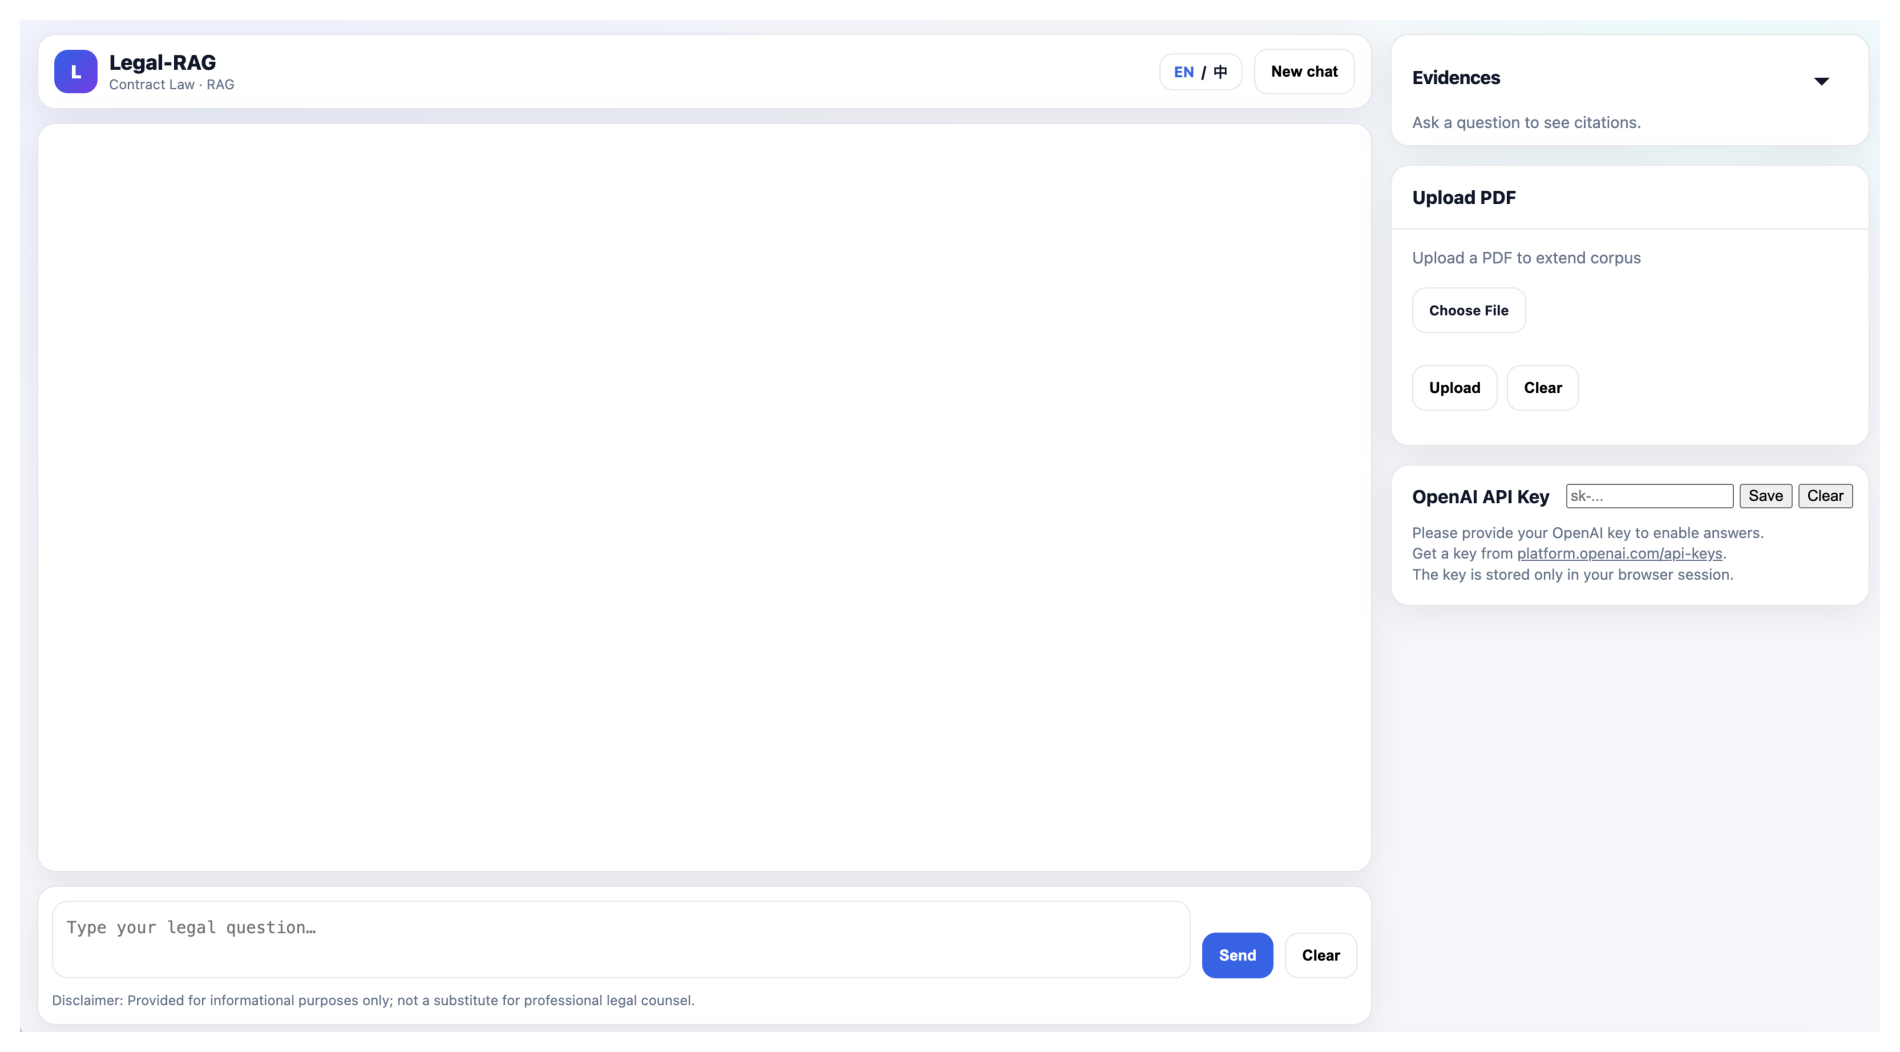

In [18]:
#| echo: false

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.figure(figsize=(12, 10), dpi=200)
img = mpimg.imread('ui/ui.png')
plt.imshow(img)
plt.axis('off')


With the UI, the complete workflow becomes:

- User submits a question via the UI or a remote client

- The request is forwarded to the local LegalRAG API

- Retrieval results are displayed

- Evidence-grounded results are returned  